# Recap - The Cars Dataset


In [1]:
# 1 - DATA MANIPULATION
import pandas as pd
import numpy as np

# 2 - DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# 3 - STATISTICS
from statsmodels.graphics.gofplots import qqplot

# 4 - MACHINE LEARNING

## 4.1 - Preprocessing

### 4.1.1 - Scalers
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

### 4.1.2 - Encoders
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

### 4.1.3 - Crossvalidation, Training, Model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

### 4.1.4 - Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics  import ConfusionMatrixDisplay

# 🚗 The Cars Dataset


👇 Import the [***ML_Cars_Recap_dataset.csv dataset***](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Cars_Recap_dataset.csv) by running the code below 

In [14]:
aws_url = "https://d32aokrjazspmn.cloudfront.net/materials/ML_Cars_Recap_dataset.csv"
cars = pd.read_csv(aws_url)
cars.head()


# Note: Storing CSV files online is common practice. This file is stored in LeWagon's AWS account.

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
0,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
1,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
2,std,65.50000,2823.0,ohcv,six,3.47,5000.0,expensive
3,std,65.88794,2337.0,ohc,four,3.40,5500.0,expensive
4,std,66.40000,2824.0,ohc,five,3.40,5500.0,expensive


In [15]:
cars.shape # 205 cars x 8 features


(205, 8)

ℹ️ The dataset description is available [here](https://drive.google.com/file/d/1giEQ6GfDPw1exbzZlE-iN2iAVk6kiZrU/view?usp=sharing).

❓ **Question (Information)** ❓ Gather some basic information about your dataset.

In [16]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   aspiration      205 non-null    object 
 1   carwidth        205 non-null    float64
 2   curbweight      205 non-null    float64
 3   enginetype      205 non-null    object 
 4   cylindernumber  205 non-null    object 
 5   stroke          205 non-null    float64
 6   peakrpm         205 non-null    float64
 7   price           205 non-null    object 
dtypes: float64(4), object(4)
memory usage: 12.9+ KB


In [17]:
cars.describe()

,carwidth,curbweight,stroke,peakrpm
count,205.000000,205.000000,205.000000,205.000000
mean,65.887940,2555.565854,3.255415,5125.121951
std,2.074414,520.680204,0.313597,476.985643
min,60.300000,1488.000000,2.070000,4150.000000
25%,64.200000,2145.000000,3.110000,4800.000000
50%,65.500000,2414.000000,3.290000,5200.000000
75%,66.500000,2935.000000,3.410000,5500.000000
max,72.300000,4066.000000,4.170000,6600.000000


# (1) 🛠 Data Preparation

## (1.0) Pre-requisites

❓ **Question (Potential anomalies)** ❓ 

- Are there any columns that need to be changed due to their data types?
    - Please make the necessary adjustments accordingly.

In [18]:
# --->  `cylindernumber` should be integers, not objects...

cars["cylindernumber"].value_counts()

cylindernumber
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64

In [19]:
cars["cylindernumber"] = cars["cylindernumber"].map(
    {"four": 4, 
    "five": 5, 
    "six": 6, 
    "eight": 8, 
    "two": 2, 
    "three": 3,
    "twelve": 12}
    )
    
cars["cylindernumber"].value_counts()

cylindernumber
4     159
6      24
5      11
8       5
2       4
3       1
12      1
Name: count, dtype: int64

## (1.1) Duplicates

❓ **Question (Duplicate rows)** ❓

Calculate the number of duplicate rows in the Cars dataset.

In [22]:
cars.duplicated()

0      False
1       True
2      False
3      False
4      False
       ...  
200    False
201    False
202    False
203    False
204    False
Length: 205, dtype: bool

In [21]:
cars.duplicated().sum()

np.int64(14)

❓ **Question (Remove duplicates)** ❓ 

In [25]:
cars = cars.drop_duplicates().reset_index(drop=True)
cars# YOUR CODE HERE

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
0,std,64.10000,2548.0,dohc,4,2.68,5000.0,expensive
1,std,65.50000,2823.0,ohcv,6,3.47,5000.0,expensive
2,std,65.88794,2337.0,ohc,4,3.40,5500.0,expensive
3,std,66.40000,2824.0,ohc,5,3.40,5500.0,expensive
4,std,66.30000,2507.0,ohc,5,3.40,5500.0,expensive
...,...,...,...,...,...,...,...,...
186,std,68.90000,2952.0,ohc,4,3.15,5400.0,expensive
187,turbo,68.80000,3049.0,ohc,4,3.15,5300.0,expensive
188,std,68.90000,3012.0,ohcv,6,2.87,5500.0,expensive
189,turbo,68.90000,3217.0,ohc,6,3.40,4800.0,expensive


## (1.2) Missing data

❓ **Question (`NaN`)** ❓

What is the percentage of `NaN` for each feature?

In [27]:
cars.isna().sum().sort_values(ascending=False) / len(cars)

aspiration        0.0
carwidth          0.0
curbweight        0.0
enginetype        0.0
cylindernumber    0.0
stroke            0.0
peakrpm           0.0
price             0.0
dtype: float64

## (1.3)  Defining the features $X$ and the target $y$

❓ **Question** ❓

- Store the features of this dataset in the variable $X$.
- Store the target in the variable $y$.

In [28]:
# Defining the target
y = cars["price"]   

# Defining the features
X = cars.drop(columns=["price"])

❓ **Question (Quick look at the target)** ❓ What is the ratio of "cheap" cars to "expensive" cars? 

In [29]:
round(y.value_counts(normalize=True), 2)

price
expensive    0.61
cheap        0.39
Name: proportion, dtype: float64

## (1.4) Scaling numerical features

❓ **Question (Quick look at numerical columns)** ❓

- Show boxplots of all numerical columns in a single line of code
- Do the same for their distributions using histograms

<Axes: ylabel='Frequency'>

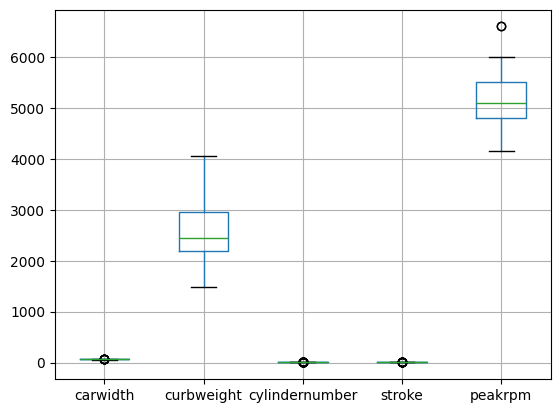

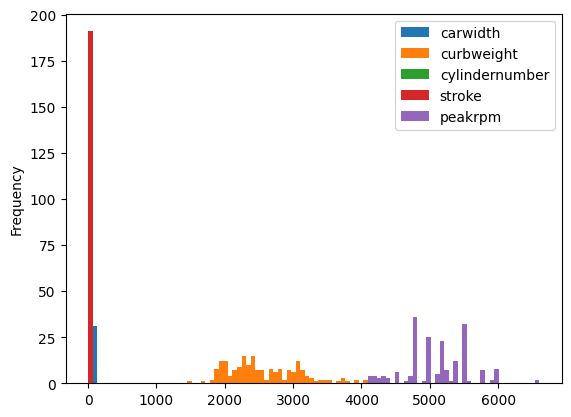

In [30]:
cars.boxplot()
cars.plot.hist(bins=100)


❓ **Question (Focus on numerical columns)** ❓

Store the numerical columns of the cars dataset in `cars_num`.

In [31]:
###########################
# Manual solution         # - not very smart
###########################

# num_features = ["carwidth", "curbweight", "cylindernumber", "stroke", "peakrpm"]
# cars_num = X[num_features]

# This is one way to select numerical features...
# But not very smart...

###########################
# Elegant solution        # - much better
###########################

cars_num = X.select_dtypes(exclude=['object']) # selecting only numerical features
cars_num


,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,64.10000,2548.0,4,2.68,5000.0
1,65.50000,2823.0,6,3.47,5000.0
2,65.88794,2337.0,4,3.40,5500.0
3,66.40000,2824.0,5,3.40,5500.0
4,66.30000,2507.0,5,3.40,5500.0
...,...,...,...,...,...
186,68.90000,2952.0,4,3.15,5400.0
187,68.80000,3049.0,4,3.15,5300.0
188,68.90000,3012.0,6,2.87,5500.0
189,68.90000,3217.0,6,3.40,4800.0


❓ **Question (Robust Scaler)** ❓

👨🏻‍🏫 Robustly scaling all numerical features is a fast and efficient scaling method.

In [32]:
# Create RobustScaler
robust_scaler = RobustScaler().set_output(transform='pandas')

# Scale and store features
cars_num_scaled = robust_scaler.fit_transform(cars_num)

# Display scaled features
cars_num_scaled

,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,-0.555556,0.135659,0.0,-2.033333,-0.142857
1,-0.037037,0.490956,2.0,0.600000,-0.142857
2,0.106644,-0.136951,0.0,0.366667,0.571429
3,0.296296,0.492248,1.0,0.366667,0.571429
4,0.259259,0.082687,1.0,0.366667,0.571429
...,...,...,...,...,...
186,1.222222,0.657623,0.0,-0.466667,0.428571
187,1.185185,0.782946,0.0,-0.466667,0.285714
188,1.222222,0.735142,2.0,-1.400000,0.571429
189,1.222222,1.000000,2.0,0.366667,-0.428571


## (1.5) Encoding categorical features

❓ **Question (Focus on categorical columns)** ❓

Store the categorical columns of the cars dataset in `cars_categorical`.

In [33]:
# Manual solution --> not very smart

# categorical_features = ["aspiration", "enginetype"]
# cars_categorical = X[categorical_features]

# Elegant solution --> much better
cars_categorical = X.select_dtypes(include=['object']) # selecting only categorical features
cars_categorical

,aspiration,enginetype
0,std,dohc
1,std,ohcv
2,std,ohc
3,std,ohc
4,std,ohc
...,...,...
186,std,ohc
187,turbo,ohc
188,std,ohcv
189,turbo,ohc


❓ **Question: If we encode the categorical features, what is the expected number of columns?** ❓

❓ **Question (OneHotEncoder): Encode the categorical features** ❓

<details>
    <summary><i>Hints</i></summary>
    
- Drop one column if a categorical feature is binary
- Use dense matrices (Sklearn estimators cannot handle sparse matrices)
- Save the results into a Pandas DataFrame named `encoded_features`
    - 💡 After fitting OHE on a DataFrame, you can access the new column names with _`get_feature_names_out()`_
    
</details>

In [34]:
cars_categorical["aspiration"].value_counts()

aspiration
std      156
turbo     35
Name: count, dtype: int64

In [35]:
round(cars_categorical["enginetype"].value_counts() / len(cars_categorical), 2)

enginetype
ohc      0.72
ohcf     0.07
ohcv     0.07
dohc     0.06
l        0.06
rotor    0.02
dohcv    0.01
Name: count, dtype: float64

In [38]:
# Initiating the OneHotEncoder
ohe = OneHotEncoder(drop="if_binary", sparse_output=False, min_frequency=0.05).set_output(transform="pandas")

# Fitting the OneHotEncoder
ohe.fit(cars_categorical)

# Printing the different categories detected by the OHE
display(ohe.categories_)

# Since Sklearn 1.1, you can retrieve the names of the generated columns
display(ohe.get_feature_names_out())

# Storing the encoded features
encoded_features = ohe.transform(cars_categorical)
encoded_features


[array(['std', 'turbo'], dtype=object),
 array(['dohc', 'dohcv', 'l', 'ohc', 'ohcf', 'ohcv', 'rotor'], dtype=object)]

array(['aspiration_turbo', 'enginetype_dohc', 'enginetype_l',
       'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv',
       'enginetype_infrequent_sklearn'], dtype=object)

,aspiration_turbo,enginetype_dohc,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_infrequent_sklearn
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
186,0.0,0.0,0.0,1.0,0.0,0.0,0.0
187,1.0,0.0,0.0,1.0,0.0,0.0,0.0
188,0.0,0.0,0.0,0.0,0.0,1.0,0.0
189,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## (1.6) Concatenating all the preprocessed features together $X_{preprocessed}$

❓ **Question (concatenating all preprocessed features together)** ❓

Concatenate `cars_num_scaled` and `encoded_features` into `X_preprocessed`.

In [39]:
X_preprocessed = pd.concat([cars_num_scaled, encoded_features], axis=1)
X_preprocessed

,carwidth,curbweight,cylindernumber,stroke,peakrpm,aspiration_turbo,enginetype_dohc,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_infrequent_sklearn
0,-0.555556,0.135659,0.0,-2.033333,-0.142857,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.037037,0.490956,2.0,0.600000,-0.142857,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.106644,-0.136951,0.0,0.366667,0.571429,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.296296,0.492248,1.0,0.366667,0.571429,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.259259,0.082687,1.0,0.366667,0.571429,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
186,1.222222,0.657623,0.0,-0.466667,0.428571,0.0,0.0,0.0,1.0,0.0,0.0,0.0
187,1.185185,0.782946,0.0,-0.466667,0.285714,1.0,0.0,0.0,1.0,0.0,0.0,0.0
188,1.222222,0.735142,2.0,-1.400000,0.571429,0.0,0.0,0.0,0.0,0.0,1.0,0.0
189,1.222222,1.000000,2.0,0.366667,-0.428571,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## (1.7) Encoding the target

❓ **Question (Encoding the categorical target)** ❓

Encode the target variable using 📚[***LabelEncoder***](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html).

In [40]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

pd.DataFrame({"target": y, "encoded_target": y_encoded}).sample(10)


,target,encoded_target
36,expensive,1
169,cheap,0
142,cheap,0
63,expensive,1
43,expensive,1
150,cheap,0
89,cheap,0
71,cheap,0
98,expensive,1
159,expensive,1


# (2) 🏋🏻‍♂️ Modeling (Logistic Regression)

🎯 Our goal is to predict whether a car will be expensive or cheap based on some features.

## (2.0) Cross-Validation

👩‍🏫 In Machine Learning, when you want to compare different models, Cross Validation is a powerful method used to roughly and robustly evaluate the performance of each sub-model.

❓ **Question (Cross Validation)** ❓

What is the potential performance of LogisticRegression for this dataset?

In [ ]:
# YOUR CODE HERE

- 🚀 This accuracy is promising, let's go further!
- 🗣 We will discuss what a good Regression / Classification model looks like in the `Performance Metrics` unit.

## (2.1) Holdout Method

❓ **Question (Holdout): Split your dataset 70% / 30% into train / test** ❓

<details>
    <summary><i>Hint</i></summary>

- You don't actually need to use `LabelEncoder` for a binary target.
    - Sklearn is smart enough to detect a binary target.
    
</details>

In [ ]:
# YOUR CODE HERE

## (2.2) Training and evaluating

❓ **Question: Train/Evaluate the Logistic Regression model** 

In [ ]:
# Create the Logistic Regression model
logreg = LogisticRegression(max_iter=100)

# Train the model
logreg.fit(X_train, y_train)

# Evaluate the model
logreg.score(X_test, y_test)

## (2.3) Predicting

❓ **Question (Predicting a new "data point")** ❓

Does your ML algorithm (the Logistic Regression you just trained) think that a car with the following features will be expensive?

In [ ]:
new_car = pd.DataFrame(columns=X.columns)
new_car.loc[0] = ['std', 65.88793969849246, 1874.0, 'ohc', 'four', 3.11, 5400.0]
new_car

> 👨🏻‍🏫 **In order to make a prediction, this new car needs to go through the same transformations that were applied on the training set!**

🌠 Take a look at the big picture of this recap [here](https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/prepare_dataset_fit_transform.png)!

In [ ]:
# 0 - Fixing anomalous data

pass  # YOUR CODE HERE

In [ ]:
# 1 - Scaling numerical features

pass  # YOUR CODE HERE

In [ ]:
# 2 - Encoding categorical features

pass  # YOUR CODE HERE

In [ ]:
# 3 - Concatenating numerical and categorical features

pass  # YOUR CODE HERE

In [ ]:
# 4 - Prediction

pass  # YOUR CODE HERE

# (3) 🧑🏿‍🏫 Warning about Data Leakage

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/cross_validation_data_leakage.png"  width=600>

🏁 Congratulations! You are now an expert in dataset preparation!
